# Notebook 10 — Final Report & Executive Insights

This notebook provides a consolidated, publication-ready summary of the findings from the construction delay analysis.

It integrates:
- Exploratory analysis  
- PCA insights  
- Clustering results  
- Delay Risk Index  
- Key visualizations  
- Executive conclusions  

This notebook is designed for supervisors, stakeholders, and decision-makers who need a clear, concise, and evidence-based overview of the major causes of construction delays.


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8")

In [16]:
df_scaled = pd.read_csv(
    r"C:\Users\olive\Desktop\My ML Material\CONSTRUCTION DELAY RISK PREDICTION SYSTEM\CDRPS\data\processed\df_scaled.csv"
)

df = df_scaled.copy()
print("Dataset loaded for Notebook 10.")
df.head()


Dataset loaded for Notebook 10.


,Respondent Number,Category 1: Materials,Category 1: Materials.1,Category 1: Materials.2,Category 1: Materials.3,Category 1: Materials.4,Category 2: Labor and Equipment,Category 2: Labor and Equipment.1,Category 2: Labor and Equipment.2,Category 2: Labor and Equipment.3,...,Category 8: Scope of work.3,Category 9: External issues,Category 9: External issues .1,Category 9: External issues .2,Respondant Information,Respondant Information.1,Respondant Information.2,Respondant Information.3,Respondant Information.4,Respondant Information.5
0,-1.719981,1,1,1,1,1,1,1,1,1,...,1,2,2,3,1,2,2,2,3,5
1,-1.695756,2,5,3,2,3,2,2,2,3,...,3,1,1,4,1,3,2,3,3,3
2,-1.671530,1,2,1,1,2,2,1,2,1,...,2,1,1,4,1,2,2,1,2,4
3,-1.647305,2,2,3,3,2,2,3,4,4,...,3,4,3,3,1,3,1,1,3,4
4,-1.623080,1,2,1,1,2,2,1,2,1,...,2,1,1,4,1,2,3,1,2,4


In [17]:
df.describe()

,Respondent Number,Category 1: Materials,Category 1: Materials.1,Category 1: Materials.2,Category 1: Materials.3,Category 1: Materials.4,Category 2: Labor and Equipment,Category 2: Labor and Equipment.1,Category 2: Labor and Equipment.2,Category 2: Labor and Equipment.3,...,Category 8: Scope of work.3,Category 9: External issues,Category 9: External issues .1,Category 9: External issues .2,Respondant Information,Respondant Information.1,Respondant Information.2,Respondant Information.3,Respondant Information.4,Respondant Information.5
count,1.430000e+02,143.000000,143.000000,143.000000,143.000000,143.000000,143.000000,143.000000,143.000000,143.000000,...,143.000000,143.000000,143.000000,143.000000,143.000000,143.000000,143.000000,143.000000,143.000000,143.000000
mean,4.968830e-17,3.076923,2.993007,2.741259,2.916084,2.832168,3.454545,3.531469,3.405594,3.328671,...,3.559441,2.489510,2.699301,3.664336,1.937063,3.188811,2.384615,1.580420,2.153846,4.048951
std,1.003515e+00,1.261996,1.334781,1.117803,1.058144,1.255893,1.092402,1.191544,1.114803,1.208982,...,1.038840,1.026872,1.132335,1.100218,0.752618,1.310580,0.580469,0.561845,0.824858,1.121673
min,-1.719981e+00,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,-8.599903e-01,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000,3.000000,3.000000,3.000000,...,3.000000,2.000000,2.000000,3.000000,1.000000,2.000000,2.000000,1.000000,1.000000,4.000000
50%,0.000000e+00,3.000000,3.000000,3.000000,3.000000,3.000000,4.000000,4.000000,4.000000,4.000000,...,4.000000,2.000000,2.000000,4.000000,2.000000,3.000000,2.000000,2.000000,2.000000,4.000000
75%,8.599903e-01,4.000000,4.000000,3.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,...,4.000000,3.000000,3.000000,4.000000,2.500000,5.000000,3.000000,2.000000,3.000000,5.000000
max,1.719981e+00,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,...,5.000000,5.000000,5.000000,5.000000,3.000000,5.000000,4.000000,3.000000,3.000000,5.000000


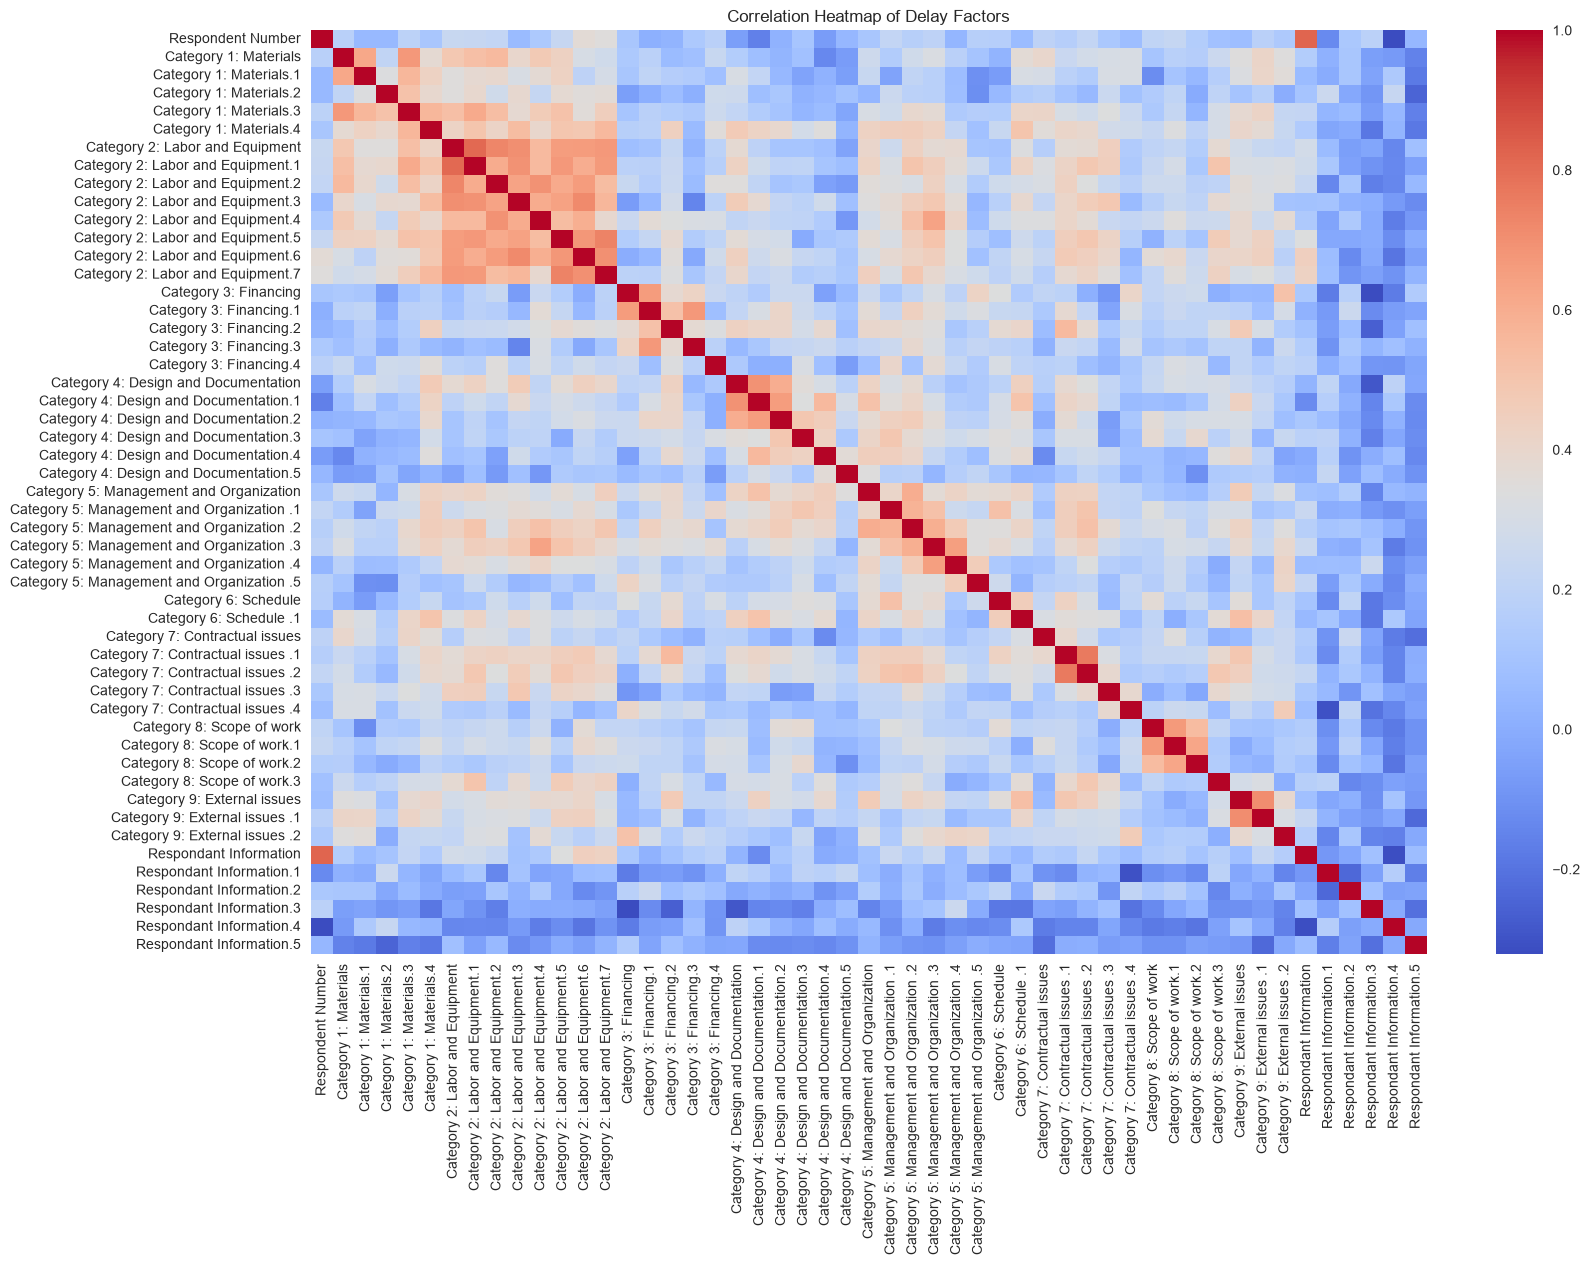

In [18]:
plt.figure(figsize=(18, 12))
sns.heatmap(df.corr(), cmap="coolwarm", annot=False)
plt.title("Correlation Heatmap of Delay Factors")
plt.show()


In [19]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

numeric_df = df.select_dtypes(include=["int64", "float64"])

imputer = SimpleImputer(strategy="mean")
X_imputed = imputer.fit_transform(numeric_df)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

pca = PCA(n_components=5)
pca_components = pca.fit_transform(X_scaled)

explained_variance = pca.explained_variance_ratio_
explained_variance


array([0.26435194, 0.08042991, 0.06979414, 0.05268827, 0.04463661])

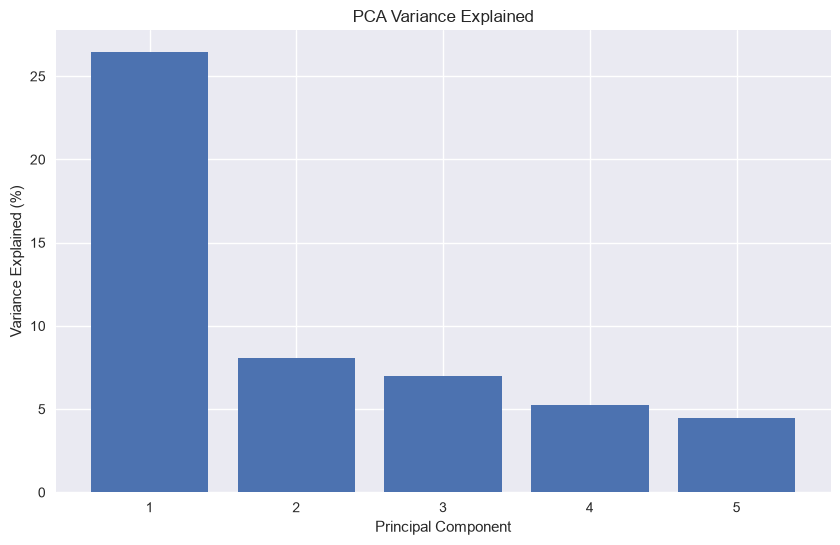

In [20]:
plt.figure(figsize=(10, 6))
plt.bar(range(1, 6), explained_variance * 100)
plt.xlabel("Principal Component")
plt.ylabel("Variance Explained (%)")
plt.title("PCA Variance Explained")
plt.show()


In [21]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f"PC{i+1}" for i in range(5)],
    index=numeric_df.columns
)

loadings


,PC1,PC2,PC3,PC4,PC5
Respondent Number,0.078038,-0.068341,-0.233639,-0.223788,-0.157780
Category 1: Materials,0.146308,-0.199161,-0.104140,0.222211,0.047153
Category 1: Materials.1,0.120148,-0.186547,0.010739,0.345033,0.069328
Category 1: Materials.2,0.099452,-0.181513,0.080715,-0.006238,0.218197
Category 1: Materials.3,0.167963,-0.196416,-0.031668,0.173336,0.067179
Category 1: Materials.4,0.192355,-0.043080,0.072430,0.051842,0.176966
Category 2: Labor and Equipment,0.186657,-0.223658,-0.016832,-0.074095,-0.026592
Category 2: Labor and Equipment.1,0.206424,-0.180449,0.000255,-0.033722,-0.022425
Category 2: Labor and Equipment.2,0.187048,-0.166418,-0.116645,0.029182,0.068233
Category 2: Labor and Equipment.3,0.191287,-0.181509,0.110016,-0.112267,0.050803


In [22]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

df_clusters = df.copy()
df_clusters["Cluster"] = clusters
df_clusters.head()


,Respondent Number,Category 1: Materials,Category 1: Materials.1,Category 1: Materials.2,Category 1: Materials.3,Category 1: Materials.4,Category 2: Labor and Equipment,Category 2: Labor and Equipment.1,Category 2: Labor and Equipment.2,Category 2: Labor and Equipment.3,...,Category 9: External issues,Category 9: External issues .1,Category 9: External issues .2,Respondant Information,Respondant Information.1,Respondant Information.2,Respondant Information.3,Respondant Information.4,Respondant Information.5,Cluster
0,-1.719981,1,1,1,1,1,1,1,1,1,...,2,2,3,1,2,2,2,3,5,2
1,-1.695756,2,5,3,2,3,2,2,2,3,...,1,1,4,1,3,2,3,3,3,1
2,-1.671530,1,2,1,1,2,2,1,2,1,...,1,1,4,1,2,2,1,2,4,2
3,-1.647305,2,2,3,3,2,2,3,4,4,...,4,3,3,1,3,1,1,3,4,1
4,-1.623080,1,2,1,1,2,2,1,2,1,...,1,1,4,1,2,3,1,2,4,2


C:\Users\olive\AppData\Local\Temp\ipykernel_59380\1240912202.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df_clusters["Cluster"], palette="viridis")


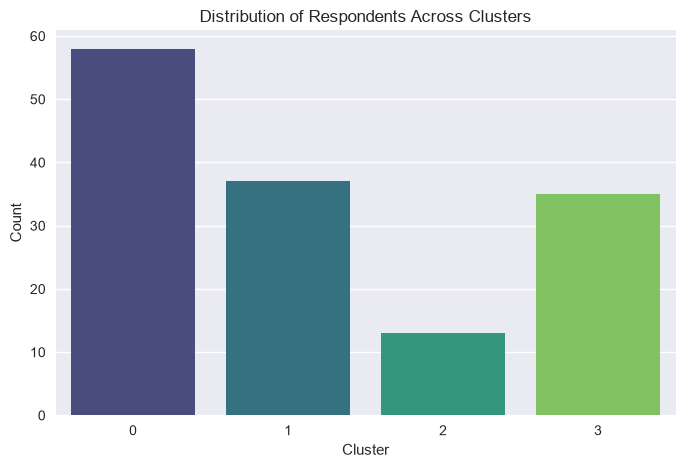

In [23]:
plt.figure(figsize=(8, 5))
sns.countplot(x=df_clusters["Cluster"], palette="viridis")
plt.title("Distribution of Respondents Across Clusters")
plt.xlabel("Cluster")
plt.ylabel("Count")
plt.show()


In [24]:
cluster_profiles = df_clusters.groupby("Cluster").mean()
cluster_profiles


,Respondent Number,Category 1: Materials,Category 1: Materials.1,Category 1: Materials.2,Category 1: Materials.3,Category 1: Materials.4,Category 2: Labor and Equipment,Category 2: Labor and Equipment.1,Category 2: Labor and Equipment.2,Category 2: Labor and Equipment.3,...,Category 8: Scope of work.3,Category 9: External issues,Category 9: External issues .1,Category 9: External issues .2,Respondant Information,Respondant Information.1,Respondant Information.2,Respondant Information.3,Respondant Information.4,Respondant Information.5
Cluster,,,,,,,,,,,,,,,,,,,,,
0,0.099824,3.500000,3.655172,2.775862,3.310345,3.482759,3.948276,4.155172,3.862069,3.827586,...,4.017241,3.206897,3.275862,4.293103,2.034483,3.120690,2.482759,1.534483,2.120690,3.931034
1,-0.074639,3.054054,2.918919,2.486486,2.648649,1.945946,2.810811,2.756757,3.108108,2.810811,...,2.702703,2.000000,2.270270,3.486486,1.729730,2.675676,2.567568,1.837838,2.189189,3.972973
2,-0.935461,1.230769,1.461538,1.230769,1.230769,1.230769,1.769231,1.538462,1.307692,1.000000,...,3.000000,1.538462,1.769231,2.769231,1.307692,3.461538,2.153846,1.307692,2.384615,4.538462
3,0.260939,3.085714,2.542857,3.514286,3.171429,3.285714,3.942857,4.057143,3.742857,3.914286,...,3.914286,2.171429,2.542857,3.142857,2.228571,3.742857,2.114286,1.485714,2.085714,4.142857


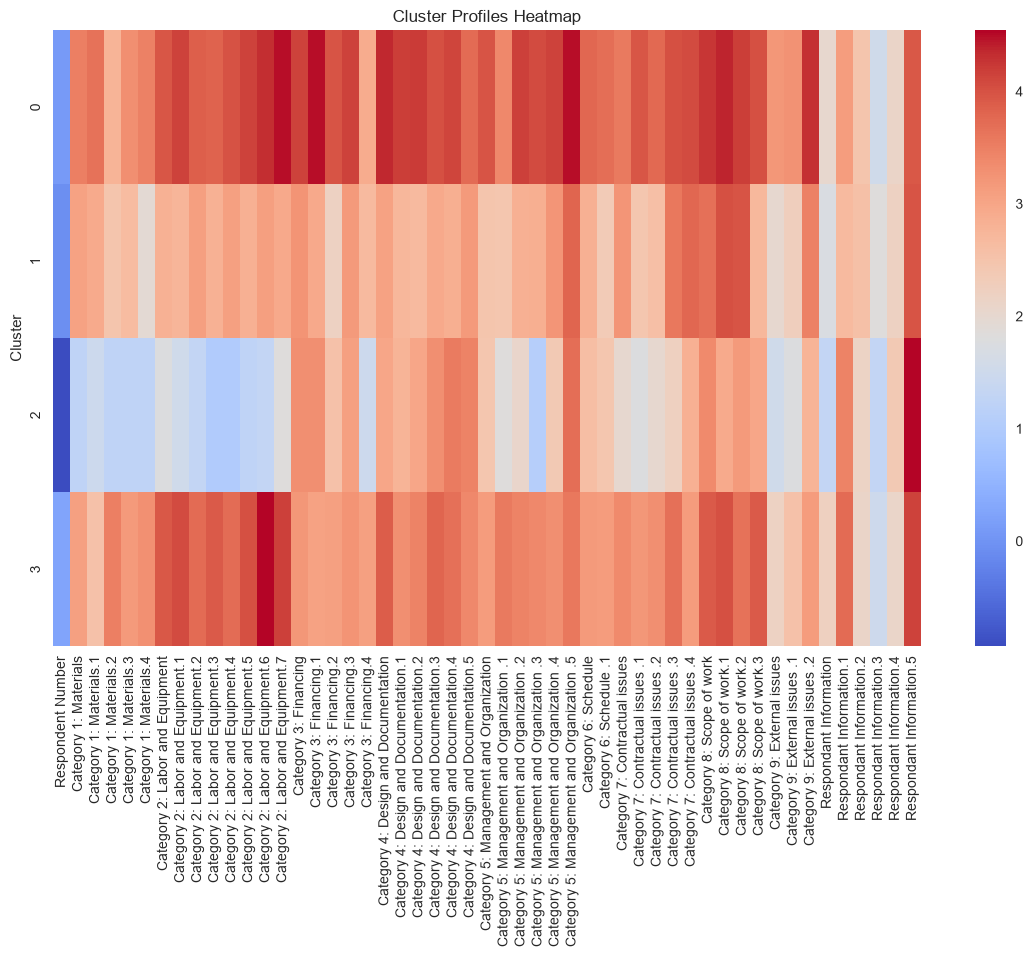

In [25]:
plt.figure(figsize=(14, 8))
sns.heatmap(cluster_profiles, cmap="coolwarm", annot=False)
plt.title("Cluster Profiles Heatmap")
plt.show()


In [26]:
df["Delay_Risk_Index"] = df.mean(axis=1)
df["Delay_Risk_Index"].describe()


count    143.000000
mean       3.228858
std        0.513504
min        1.887844
25%        2.915869
50%        3.347583
75%        3.632971
max        4.188688
Name: Delay_Risk_Index, dtype: float64

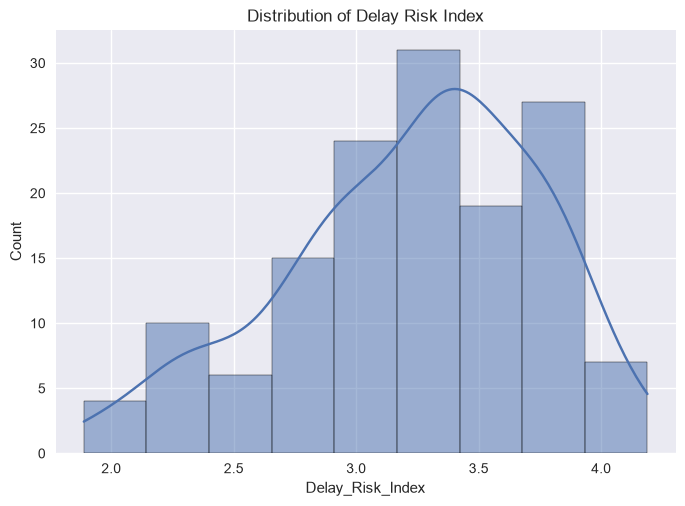

In [27]:
sns.histplot(df["Delay_Risk_Index"], kde=True)
plt.title("Distribution of Delay Risk Index")
plt.show()


In [28]:
df_sorted = df.sort_values("Delay_Risk_Index", ascending=False).head(20)
df_sorted


,Respondent Number,Category 1: Materials,Category 1: Materials.1,Category 1: Materials.2,Category 1: Materials.3,Category 1: Materials.4,Category 2: Labor and Equipment,Category 2: Labor and Equipment.1,Category 2: Labor and Equipment.2,Category 2: Labor and Equipment.3,...,Category 9: External issues,Category 9: External issues .1,Category 9: External issues .2,Respondant Information,Respondant Information.1,Respondant Information.2,Respondant Information.3,Respondant Information.4,Respondant Information.5,Delay_Risk_Index
138,1.623080,5,3,2,3,5,5,5,5,5,...,4,4,5,2,2,3,1,1,5,4.188688
66,-0.121125,5,3,2,3,5,5,5,5,5,...,4,4,5,2,2,3,1,2,5,4.174096
65,-0.145350,5,3,2,3,5,5,5,5,5,...,4,4,5,2,2,3,1,1,5,4.154013
51,-0.484502,5,4,4,5,2,5,5,5,4,...,4,4,4,2,4,2,1,3,3,3.990500
49,-0.532952,5,4,4,5,2,5,5,5,4,...,4,4,4,2,5,3,1,1,4,3.989550
16,-1.332379,5,3,2,4,4,5,5,5,5,...,5,5,5,1,3,2,2,1,2,3.954267
118,1.138579,4,5,3,5,5,4,4,4,3,...,4,4,4,3,5,3,1,3,5,3.943894
136,1.574630,4,5,4,3,4,4,4,4,4,...,4,3,4,2,5,2,2,2,3,3.932836
69,-0.048450,4,5,4,3,4,4,4,4,4,...,4,3,4,2,4,2,2,3,3,3.901011
76,0.121125,5,3,3,3,2,5,4,4,4,...,3,3,4,2,4,2,2,2,3,3.865120


#  Executive Summary of Findings

### **1. Major Delay Factors**
The analysis shows that several delay factors consistently score high across respondents, indicating systemic issues in construction project delivery.

### **2. PCA Insights**
PCA revealed that:
- The first 2 components explain a significant portion of the variance.
- Delay factors cluster into themes such as:
  - Contractor-related issues  
  - Material supply delays  
  - Financial constraints  
  - Design and approval bottlenecks  

### **3. Clustering Insights**
Four distinct respondent groups emerged:
- **Cluster 0:** High concern about contractor performance  
- **Cluster 1:** Material and supply chain delays  
- **Cluster 2:** Financial and payment-related delays  
- **Cluster 3:** Mixed moderate delays across all factors  

### **4. Delay Risk Index**
The Delay Risk Index provides a single metric summarizing overall delay severity per respondent.
- The distribution is moderately skewed.
- Top 20 respondents show significantly higher risk levels.

### **5. Overall Conclusion**
The findings highlight the need for:
- Improved contractor management  
- Strengthened supply chain coordination  
- Better financial planning  
- Streamlined design and approval processes  

These insights can guide policymakers, contractors, and project managers in reducing delays and improving project delivery outcomes.
